In [1]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np

# Stadardised Formation Cycling
exp = pybamm.Experiment( [("Charge at C/20 until 4.2 V",
                           "Hold at 4.2 V for 1 hours", 
                           "Hold at 4.2 V until 2.5 mA", 
                           "Discharge at C/20 until 2.5 V",
                           "Charge at C/20 until 3.8 V",
                           "Hold at 4.8 V for 1 hours"
                           )])
# no_cycles = 2
# exps = [pybamm.Experiment(
#     [("Charge at {} until 4.2 V".format(c_rates[i]),
#       "Rest for 5 hours",
#       "Discharge at {} until 2.5 V".format(c_rates[i]),
#       "Rest for 5 hours",
#       )] * no_cycles,
# ) for i in range(len(c_rates))]

param = pybamm.ParameterValues("Chen2020")
param['Initial inner SEI thickness [m]'] = 1e-12
param['Initial outer SEI thickness [m]'] = 1e-12

pybamm.settings.max_y_value = 1000000000
solver = pybamm.CasadiSolver(mode="safe")

/home/kawamanmi/Projects/PyBaMM


In [2]:
model = pybamm.lithium_ion.DFN()
sims = [(pybamm.Simulation(model, parameter_values=param,
                           experiment=exp, solver=solver)) for exp in exps]
sims

In [3]:
# model.variable_names()

In [4]:
sols = []
sols.extend(sim.solve(initial_soc=0) for sim in sims)

At t = 368.811 and h = 5.97115e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 368.857 and h = 1.08571e-14, the corrector convergence failed repeatedly or with |h| = hmin.


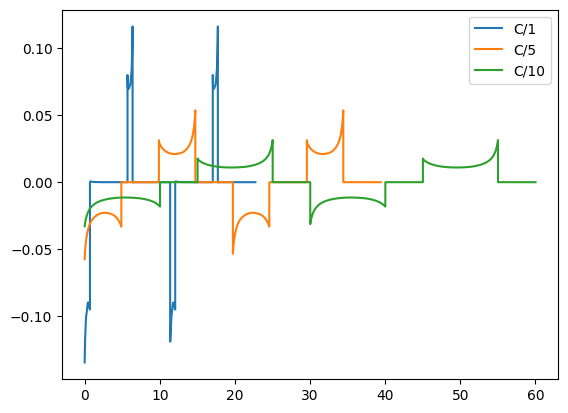

In [5]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm
for index in range(len(sols)):
    plt.plot(sols[index]["Time [h]"].entries,
             sols[index]['X-averaged negative electrode reaction overpotential [V]'].entries, label=c_rates[index])
plt.legend()